In [1]:
import pandas as pd
from tokenizers import Tokenizer
from tqdm import tqdm
import matplotlib.pyplot as plt

In [18]:
import pandas as pd
import pyarrow.parquet as pq
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, processors
import os
from tqdm import tqdm
import math
import gc
import numpy as np

# ============================================================
# CONFIGURAÇÕES
# ============================================================
TSV_PATH = '/media/alvarinho/dados/Datasets/refined/traducao/analise_textos.tsv'
SPLIT_PARQUET_PATH = '/media/alvarinho/dados/Datasets/refined/traducao/analise_textos_split.parquet'

# ============================================================
# FUNÇÕES DE LEITURA E PREPARAÇÃO
# ============================================================
def load_train_indices(parquet_path, batch_size=1_000_000, target_sample_size=1_000_000):
    print('Carregando metadados de split em lotes...')
    parquet_file = pq.ParquetFile(parquet_path)
    
    # Dicionário temporário para guardar arrays numéricos, que são muito leves
    train_indices = {}
    split_counts = {}
    
    total_linhas = parquet_file.metadata.num_rows
    
    # Lemos APENAS as 3 colunas necessárias para o sorteio, poupando muita RAM e CPU
    with tqdm(total=total_linhas, desc='Mapeando indices', unit='linhas') as pbar:
        for batch in parquet_file.iter_batches(
            batch_size=batch_size, 
            columns=['dataset_id', 'index', 'split']
        ):
            linhas_neste_lote = batch.num_rows 
            df_chunk = batch.to_pandas()
            
            # Contagem global
            counts = df_chunk['split'].value_counts().to_dict()
            for split_name, count in counts.items():
                split_counts[split_name] = split_counts.get(split_name, 0) + count
                
            # Filtra apenas o split de treino
            df_train = df_chunk[df_chunk['split'] == 'train']
            
            # Agrupa e guarda os arrays do numpy
            for dataset_id, group in df_train.groupby('dataset_id', observed=True):
                if dataset_id not in train_indices:
                    train_indices[dataset_id] = []
                
                train_indices[dataset_id].append(group['index'].values)
                
            del df_chunk
            del df_train
            gc.collect()
            
            pbar.update(linhas_neste_lote)

            indices = list(train_indices.values())
            if len(np.concatenate(indices) >= target_sample_size):
                break
            
    return train_indices

In [44]:
def get_text_iterator(tsv_path, train_indices, batch_size=10000):
    """
    Lê o arquivo TSV linha por linha, faz o split pelas marcações,
    injeta a tag de tradução no texto de origem e yield dos textos.
    """
    batch = []
    
    with open(tsv_path, 'r', encoding='utf-8') as f:
        
        for line in f:
            line = line.rstrip('\n')
            
            try:
                meta_part, texts_part = line.split('<METADATA>')
                dataset_id, idx_str = meta_part.split('<SEP>')
                text1, text2 = texts_part.split('<SEP>')
                
                    
                # ====================================================
                # INJEÇÃO DA TAG DE TRADUÇÃO (Approach 1)
                # ====================================================
                # Verifica o sufixo do dataset_id para saber a direção[cite: 2]
                if dataset_id.endswith('_en_pt'):
                    text1_modificado = f"<2pt> {text1}"
                elif dataset_id.endswith('_en_es'):
                    text1_modificado = f"<2es> {text1}"
                else:
                    text1_modificado = text1 # Fallback de segurança
                    
                # Adiciona o texto em inglês (com a tag) e o texto alvo ao lote
                batch.extend([text1_modificado, text2])
                
                if len(batch) >= batch_size:
                    yield batch
                    batch = []
                    
            except ValueError:
                # Passa silenciosamente por linhas mal formatadas
                continue
                
    if batch:
        yield batch


In [45]:
indices = load_train_indices(SPLIT_PARQUET_PATH)

Carregando metadados de split em lotes...


Mapeando indices:   0%|          | 587969/445313325 [00:00<01:10, 6294946.24linhas/s]


In [78]:
import pandas as pd
from tqdm import tqdm

iterator_train = get_text_iterator(TSV_PATH, indices, batch_size=1)

# Usamos uma lista simples para armazenar os dados temporariamente
data = []

# Um único tqdm é suficiente
for batch in tqdm(iterator_train, total=1_000_000, desc='Mapeando indices', unit='linhas'):
    # Salvamos como uma tupla, que é leve e rápida
    data.append((batch[0], 'src'))
    data.append((batch[1], 'tgt'))
    if len(data) == 2_000_000:
        break

# Criamos o DataFrame de uma vez só no final (MUITO mais rápido)
df_train = pd.DataFrame(data, columns=['lang', 'type'])

Mapeando indices: 100%|█████████▉| 999999/1000000 [00:01<00:00, 657257.79linhas/s]


In [79]:
df_train.head()

,lang,type
0,<2es> EUROPEAN PUBLIC ASSESSMENT REPORT (EPAR),src
1,INFORME PÚBLICO EUROPEO DE EVALUACIÓN (EPAR),tgt
2,<2es> EPAR summary for the public,src
3,Resumen del EPAR para el público general,tgt
4,<2es> This document is a summary of the Europe...,src


In [80]:
tokenizer = Tokenizer.from_file('artifacts/tokenizer_en_pt_es_30000.json')

In [81]:
tokenizer.encode('Olá mundo, meu nome é João').tokens

['<BOS>',
 'Ol',
 'á</w>',
 'mundo</w>',
 ',</w>',
 'meu</w>',
 'nome</w>',
 'é</w>',
 'João</w>',
 '<EOS>']

In [82]:
tokenizer.encode('Olá mundo, meu nome é João').ids

[5, 8864, 2696, 5569, 2661, 13699, 11483, 2707, 24423, 6]

In [83]:
tokenizer.decode(tokenizer.encode('Olá mundo, meu nome é João').ids)

'Olá mundo , meu nome é João'

In [86]:
df_train['lang_length'] = df_train['lang'].str.len()

In [87]:
df_train.head()

,lang,type,lang?_length,lang_length
0,<2es> EUROPEAN PUBLIC ASSESSMENT REPORT (EPAR),src,46,46
1,INFORME PÚBLICO EUROPEO DE EVALUACIÓN (EPAR),tgt,44,44
2,<2es> EPAR summary for the public,src,33,33
3,Resumen del EPAR para el público general,tgt,40,40
4,<2es> This document is a summary of the Europe...,src,81,81


In [88]:
vocabs_sizes = [30_000, 50_000, 60_000, 120_000, 150_000]

print('Declaring tokenizer...')
for vocab_size in tqdm(vocabs_sizes):
    tokenizer = Tokenizer.from_file(f'artifacts/tokenizer_en_pt_es_{vocab_size}.json')
    
    df_train[f'len_tokens_{vocab_size}'] = df_train['lang'].apply(lambda x: len(tokenizer.encode(x).ids))

    df_train[f'compress_{vocab_size}'] = df_train.apply(lambda x: x[f'len_tokens_{vocab_size}'] / x['lang_length'], axis=1)

Declaring tokenizer...


100%|██████████| 5/5 [04:09<00:00, 49.99s/it]


In [89]:
columns_compress = [x for x in df_train.columns if 'compress' in x]
rename_columns = {x: x.replace('compress_', '') for x in columns_compress}
df_stats = df_train[columns_compress].rename(columns=rename_columns).describe()
df_stats

,30000,50000,60000,120000,150000
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,3.119020e-01,2.892501e-01,2.821377e-01,2.588976e-01,2.536911e-01
std,9.634577e-02,8.860776e-02,8.602394e-02,7.882983e-02,7.677998e-02
min,1.415094e-01,1.292517e-01,1.292517e-01,9.003215e-02,9.003215e-02
25%,2.485876e-01,2.313433e-01,2.264151e-01,2.093023e-01,2.058824e-01
50%,2.835821e-01,2.640449e-01,2.586207e-01,2.380952e-01,2.328767e-01
75%,3.437500e-01,3.188406e-01,3.111111e-01,2.837838e-01,2.782711e-01
max,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00


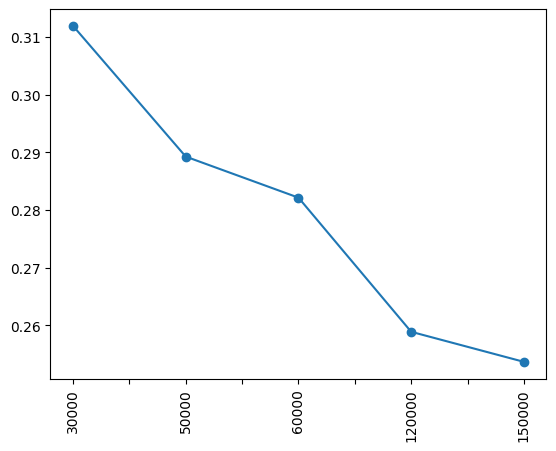

In [90]:
df_stats.T['mean'].plot.line(marker='o')
plt.xticks(rotation=90)
plt.show()

In [33]:
columns_tokens = [x for x in df_train.columns if 'len_tokens_' in x]
df_train[columns_tokens].describe(percentiles=[0.25, .5, .75, .8,.9, .95])


,len_tokens_500,len_tokens_1000,len_tokens_5000,len_tokens_10000,len_tokens_25000,len_tokens_30000,len_tokens_50000
count,802483.000000,802483.000000,802483.000000,802483.000000,802483.000000,802483.000000,802483.000000
mean,102.434956,59.115804,37.676738,34.209466,31.465717,31.101389,30.322110
std,14.751604,9.124477,6.215651,5.586211,5.123399,5.072898,4.983554
min,68.000000,34.000000,21.000000,18.000000,17.000000,17.000000,16.000000
25%,91.000000,52.000000,33.000000,30.000000,28.000000,27.000000,27.000000
50%,99.000000,57.000000,37.000000,33.000000,31.000000,30.000000,30.000000
75%,111.000000,65.000000,41.000000,38.000000,35.000000,34.000000,33.000000
80%,115.000000,67.000000,43.000000,39.000000,36.000000,35.000000,34.000000
90%,125.000000,72.000000,46.000000,42.000000,39.000000,38.000000,37.000000
95%,133.000000,77.000000,49.000000,45.000000,41.000000,40.000000,40.000000
